In [ ]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma
from langchain_anthropic import ChatAnthropic
from langsmith import Client
from dotenv import load_dotenv

load_dotenv()

embedding = UpstageEmbeddings(model="solar-embedding-1-large")

# database = Chroma.from_documents(
#     documents=splits,
#     embedding=embedding,
#     collection_name='chroma-tax',
#     persist_directory='./preprocessed-upstage'
# )

database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= './preprocessed-upstage',
  embedding_function= embedding     
)

retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 4,
        'fetch_k': 10,
        'lambda_mult': 0.6
    }
)

client = Client()

# 비용의 80%는 Haiku가, 정확도의 80%는 Sonnet/Opus가!!

smart_llm = ChatAnthropic(
    model='claude-opus-4-5-20251101',
    temperature= 0
)

llm = ChatAnthropic(
    model='claude-sonnet-4-5-20250929',
    temperature= 0
)

small_llm = ChatAnthropic(
    model='claude-haiku-4-5-20251001',
    temperature= 0
)

In [2]:
from langchain_community.tools.tavily_search import TavilySearchResults

search_tool = TavilySearchResults()

In [3]:
from langchain_core.tools.retriever import create_retriever_tool
from langchain_core.prompts import PromptTemplate

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='search_tax_law',  # 동사로 시작하는 이름 권장
    description='''소득세 관련 법령 조문을 검색합니다.

이럴 때 사용:
- 과세표준 계산 근거가 필요할 때
- 세율표, 공제 조건 등 법적 기준 확인
- 특정 조문 번호로 검색 (예: "종부세법 9조")

이럴 때 사용하지 마세요:
- 단순 세금 계산 → calculate_tax 도구
- 최신 공시가격/공정시장가액비율 → web_search 도구

반환: 관련 법령 조문 (최대 4개, 출처 포함)
''',
    document_prompt=PromptTemplate.from_template(
        "[{source} {article}]\n{page_content}"
    ),
    document_separator="\n\n"
)

In [5]:
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.utilities.semanticscholar import SemanticScholarAPIWrapper


@tool       # 데코레이터 @tool로 감싸고
def add(num1: int, num2: int) -> int:     # 함수와 변수의 이름, typehint가 schema(구조)로서, JSON 형식으로 LLM에 전달됨
    '''
    정수 num1와 num2를 더합니다. 
    '''         # 이 부분의 description(프롬프트와 같음)도 마찬가지로 LLM에 전달됨
    return num1+num2

@tool
def multiply(num1: int, num2: int) -> int:
    '''
    정수 num1와 num2를 곱합니다. 
    '''
    return num1*num2

@tool
def search(query: str) -> str:
    '''
    사용자의 질문에 알고 있는 지식만으로 답변하기 힘든 경우,
    주어진 query에 대해 DuckDuckGo 검색을 수행하고, 요약된 결과를 반환합니다.
    '''
    # 1. 검색 수행
    results = search_tool.invoke(query)
    
    # 2. 요약 프롬프트
    prompt = ChatPromptTemplate.from_messages([
        ("system", "당신은 검색 결과를 요약하는 전문가입니다. 검색 결과를 바탕으로 사용자의 질문에 간결하고 정확하게 답변하세요."),
        ("human", "질문: {query}\n\n검색 결과:\n{results}\n\n위 검색 결과를 바탕으로 질문에 답변해주세요.")
    ])
    
    # 3. Chain 구성 (비용 절약을 위해 small_llm 사용)
    chain = prompt | small_llm | StrOutputParser()
    
    # 4. 요약 실행
    summary = chain.invoke({"query": query, "results": results})
    
    return summary


semantic_scholar_wrapper = SemanticScholarAPIWrapper(
    top_k_results=5,
    doc_content_chars_max=6000,  # 더 긴 초록
)

@tool
def search_semantic_scholar(query: str) -> str:
    '''
    Semantic Scholar에서 peer-reviewed 학술 논문을 검색합니다.
    인용 수(citation count)가 포함되어 논문 품질을 판단할 수 있습니다.
    
    Args:
        query: 검색어 (예: "LLM agent reasoning")
    '''
    return semantic_scholar_wrapper.run(query)




In [6]:
@tool
def search_income_tax_law(query: str) -> str:
    '''소득세 관련 법령 조문을 검색합니다.

    이럴 때 사용:
    - 과세표준 계산 근거가 필요할 때
    - 세율표, 공제 조건 등 법적 기준 확인
    - 특정 조문 번호로 검색 (예: "소득세법 55조")

    이럴 때 사용하지 마세요:
    - 단순 세금 계산 → calculate_tax 도구
    - 최신 세율/공제 한도 → web_search 도구

    반환: 관련 법령 조문 (최대 4개, 출처 포함)
    '''
    try:
        docs = retriever.invoke(query)
    except Exception as e:
        return f"검색 중 오류 발생: {str(e)}"
    
    if not docs:
        return "관련 법령을 찾지 못했습니다. 다른 키워드로 검색해주세요."
    
    # 중복 조문 제거
    seen = set()
    unique_docs = []
    for doc in docs:
        key = doc.metadata.get('article', doc.page_content[:50])
        if key not in seen:
            seen.add(key)
            unique_docs.append(doc)
    
    # 포맷팅
    results = []
    for doc in unique_docs[:4]:
        source = doc.metadata.get('source', '출처 미상')
        article = doc.metadata.get('article', '')
        results.append(f"[{source} {article}]\n{doc.page_content}")
    
    return "\n\n".join(results)

In [10]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search, search_semantic_scholar, search_income_tax_law]

llm_with_tools = small_llm.bind_tools(tool_list)

tool_node = ToolNode(tool_list)

In [11]:
from langgraph.graph import START, END
from langgraph.graph import MessagesState, StateGraph

def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

def should_continue(state: MessagesState):
    messages = state['messages']
    if messages[-1].tool_calls:
        return 'tools'
    return END

graph_builder = StateGraph(MessagesState)


graph_builder.add_node('agent', agent) 
graph_builder.add_node('tools', tool_node)

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent', 
    should_continue,
    {
        'tools': 'tools',
        END: END
    }
)
graph_builder.add_edge('tools', 'agent')

## 여기서 checkpoint 선언

In [12]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

In [13]:
graph = graph_builder.compile(
    checkpointer=checkpointer
)

In [14]:
config = {
    'configurable': {
        'thread_id': 'test-thread-001'
    }
}

In [ ]:
from langchain_core.messages import HumanMessage


for chunk in graph.stream(
    {'messages': [HumanMessage("소득세 과세표준 계산 방법")]}, config=config,stream_mode= 'values'):
    chunk['messages'][-1].pretty_print()

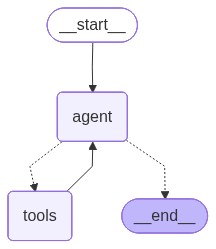

In [9]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))